In [1]:
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.autograd import Variable

import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils

import numpy as np

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)

cuda:0


In [3]:
# Batch size during training
batch_size = 100

num_workers = 2

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 32

# Number of training epochs
num_epochs = 100

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.9

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

In [4]:
# CIFAR10 dataset
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=num_workers)

testset = datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=num_workers)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


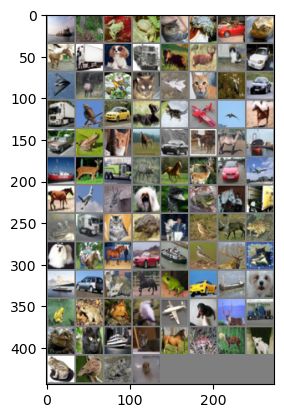

ship  deer  frog  frog  cat   frog  car   frog  horse truck dog   truck dog   deer  cat   car   plane deer  bird  cat   plane cat   bird  car   truck bird  car   deer  cat   plane bird  horse car   frog  cat   horse car   horse horse ship  ship  deer  truck deer  horse deer  car   plane horse plane deer  dog   bird  frog  horse truck frog  truck cat   frog  horse bird  deer  frog  dog   horse horse car   ship  bird  deer  cat   ship  car   cat   horse frog  car   ship  dog   frog  frog  frog  bird  plane dog   deer  truck frog  cat   ship  cat   horse frog  deer  dog   frog  bird  frog  dog  


In [5]:
# sampling CIFAR10 images
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# sample images from training dataset
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images and labels
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [6]:
# Model definition for CIFAR10
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 5)
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 12 * 12, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.conv1(x) # 28 * 28
        x = F.relu(x)
        x = self.conv2(x) # 24 * 24
        x = F.relu(x)
        x = self.pool(x) # 12 * 12
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

net = Net()
net.to(device)

Net(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [7]:
# loss function and optimization function for CIFAR10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=lr)

In [8]:
# CIFAR10 Training
for epoch in range(num_epochs):  # loops over dataset

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data[0].to(device), data[1].to(device)
        
        # initialize gradiants to zero
        optimizer.zero_grad()

        # forward, backward
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 200 == 199:    # batch size=100, so 600 batch calls for training data
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,   200] loss: 0.186
[1,   400] loss: 0.156
[2,   200] loss: 0.141
[2,   400] loss: 0.137
[3,   200] loss: 0.129
[3,   400] loss: 0.126
[4,   200] loss: 0.120
[4,   400] loss: 0.118
[5,   200] loss: 0.111
[5,   400] loss: 0.111
[6,   200] loss: 0.105
[6,   400] loss: 0.104
[7,   200] loss: 0.100
[7,   400] loss: 0.099
[8,   200] loss: 0.094
[8,   400] loss: 0.095
[9,   200] loss: 0.090
[9,   400] loss: 0.089
[10,   200] loss: 0.086
[10,   400] loss: 0.085
[11,   200] loss: 0.081
[11,   400] loss: 0.082
[12,   200] loss: 0.077
[12,   400] loss: 0.078
[13,   200] loss: 0.075
[13,   400] loss: 0.075
[14,   200] loss: 0.070
[14,   400] loss: 0.072
[15,   200] loss: 0.067
[15,   400] loss: 0.069
[16,   200] loss: 0.065
[16,   400] loss: 0.065
[17,   200] loss: 0.062
[17,   400] loss: 0.063
[18,   200] loss: 0.059
[18,   400] loss: 0.060
[19,   200] loss: 0.056
[19,   400] loss: 0.057
[20,   200] loss: 0.053
[20,   400] loss: 0.055
[21,   200] loss: 0.051
[21,   400] loss: 0.052
[22,   200

In [9]:
# saving weights for CIFAR10
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

In [10]:
# accuracy testing
correct = 0
total = 0

with torch.no_grad(): # testing, no gradient update
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        # only run forward
        outputs = net(images)
        # the highest energy class = prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of image classifier on CIFAR10 test images: {100 * correct // total} %')

Accuracy of image classifier on CIFAR10 test images: 65 %


In [11]:
# counting correct predictions per class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# testing, no gradient update
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # update correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 68.2 %
Accuracy for class: car   is 74.5 %
Accuracy for class: bird  is 57.4 %
Accuracy for class: cat   is 47.2 %
Accuracy for class: deer  is 55.8 %
Accuracy for class: dog   is 53.7 %
Accuracy for class: frog  is 75.9 %
Accuracy for class: horse is 68.6 %
Accuracy for class: ship  is 78.8 %
Accuracy for class: truck is 74.4 %
